In [5]:
import os.path

from tools import  *
import random
import matplotlib.pyplot as plt
from PIL import Image
import math
import os

In [48]:
def show_images(image_file_path_list, title_list=None, col_num=4):
    sum_num = len(image_file_path_list)
    if sum_num < col_num:
        col_num = len(image_file_path_list)
    row_num = math.ceil(sum_num / col_num) # 行数
    plt.figure(figsize=(10,5)) #设置窗口大小
    for row_i in range(row_num):
        for col_i in range(col_num):
            index = row_i * col_num + col_i
            if index >= sum_num:
                break
            img_file_path = image_file_path_list[index]
            img = Image.open(img_file_path)
            plt.subplot(row_num, col_num, row_i * col_num + col_i + 1)
            if title_list:
                plt.title(title_list[index])
            plt.imshow(img), plt.axis('off')

In [49]:
image_dir_path = 'images/'

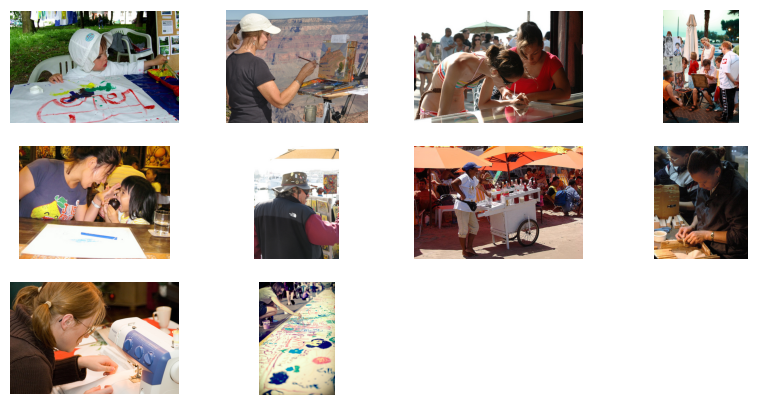

In [56]:
image_id_list = ['3635194562', '7117115809', '2466420387', '2612125121', '4978901111', '4689487867', '2978040423', '86112875', '118939364', '4768270751']
image_file_path_list = [os.path.join(image_dir_path, '{}.jpg'.format(img_id)) for img_id in image_id_list]
show_images(image_file_path_list)

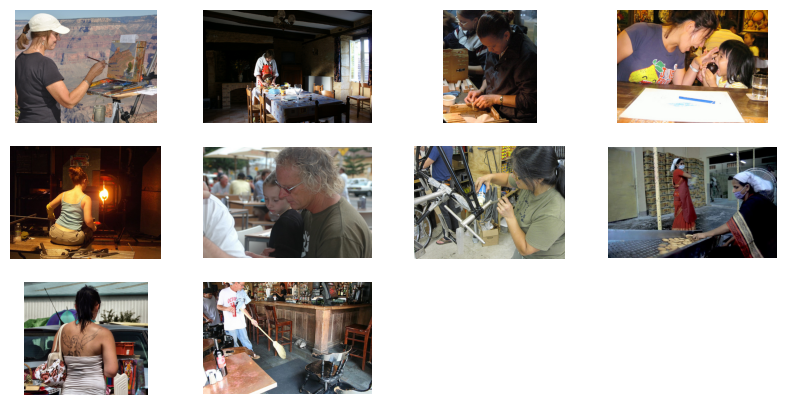

In [57]:
image_id_list = ['7117115809', '2743465453', '86112875', '4978901111', '86120682', '287212060', '6728801573', '2174648405', '4759710534', '491987177']
image_file_path_list = [os.path.join(image_dir_path, '{}.jpg'.format(img_id)) for img_id in image_id_list]
show_images(image_file_path_list)

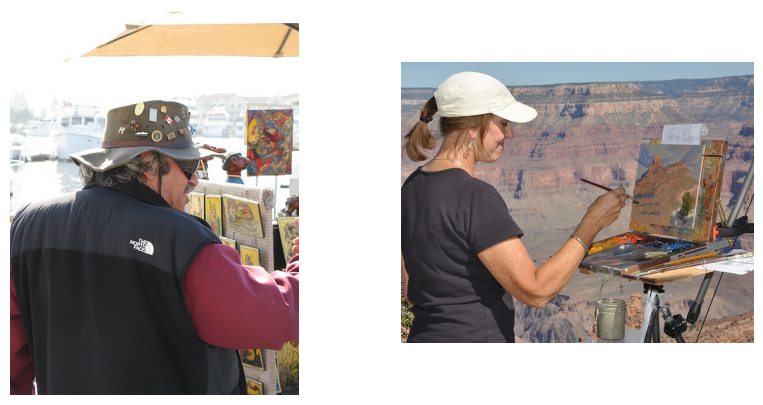

In [59]:
image_id_list = ['4689487867', '7117115809']
image_file_path_list = [os.path.join(image_dir_path, '{}.jpg'.format(img_id)) for img_id in image_id_list]
show_images(image_file_path_list)

## 绘制热力图（舍弃）

In [11]:
import torch
from pyecharts.charts import *
from pyecharts import options as opts
import json
import random

In [5]:
model_name_list = ['align-base', 'clipseg-rd64-refined', 'clip-vit-base-patch32', 'groupvit-gcc-yfcc']
sub_test_sen_to_ids = json.load(open('../V6/data/sub_test_sen_to_ids.json', 'r', encoding='utf-8'))
test_img_ids = [json.loads(line.strip()) for line in open('../V6/retrieval/data/test_img_ids.json', 'r', encoding='utf-8')]
new_text_to_enhanced = json.load(open('../V6/retrieval/data/new_text_to_enhanced_v2.json', 'r', encoding='utf-8'))

In [6]:
# 加入原query
for name in model_name_list:
    image_features = torch.load('../V6/retrieval/data/image_features_{}.pt'.format(name), map_location=torch.device('cpu'))
    image_features = torch.stack(image_features).view(1000, -1)
    all_text_features = torch.load('../V6/retrieval/data/enhanced_text_features_v2_{}.pt'.format(name), map_location=torch.device('cpu'))


    origin_text_features = torch.load('../V6/retrieval/data/text_features_{}.pt'.format(name), map_location=torch.device('cpu'))

    origin_text_features /= origin_text_features.norm(dim=-1, keepdim=True)

    image_features /= image_features.norm(dim=-1, keepdim=True)
    enhance_recall = []
    text_sims = {}
    for i, (text, enhance_list) in enumerate(new_text_to_enhanced.items()):
        type = sub_test_sen_to_ids[text]['type']

        text_features = torch.cat([all_text_features[i], origin_text_features[i].view(1, -1)], 0)
        text_features /= text_features.norm(dim=-1, keepdim=True)

        similarity = (100.0 * text_features @ image_features.T).softmax(dim=-1)
        # print(similarity.shape)
        text_sims[text] = similarity
    break

In [7]:
text = 'a tall wedge'
text_list = new_text_to_enhanced[text] + [text]
sims = text_sims[text]
num = 20

In [8]:
sub_test_sen_to_ids[text]['images'],

['3909552008']

In [10]:
image_index_list = torch.sort(sims[0], descending=True)[1][:num].tolist()
random.shuffle(image_index_list)
# image_index_list += torch.sort(sims[0], descending=False)[1][:18].tolist()

NameError: name 'random' is not defined

In [206]:
topk_sims = []
for i in range(sims.shape[0]):
    topk_sims.append(sims[i][image_index_list] / sum(sims[i][image_index_list]))

In [194]:
a = sims[0][image_index_list]
a / sum(a)

tensor([5.9446e-01, 4.0542e-01, 3.4351e-06, 3.6309e-06, 4.0848e-06, 5.6091e-06,
        5.6470e-06, 6.0075e-06, 6.2588e-06, 6.3080e-06, 7.1539e-06, 7.3181e-06,
        7.6540e-06, 7.7302e-06, 7.8916e-06, 8.1082e-06, 8.5448e-06, 8.7700e-06,
        9.0410e-06, 9.0507e-06])

In [ ]:
sims[0][image_index_list]

In [207]:
data = [[i, j, topk_sims[j][i].item()] for i, img_i in enumerate(image_index_list) for j in range(len(text_list))]

In [208]:

heat = (
    HeatMap()
    .add_xaxis([str(i) for i in image_index_list])
    .add_yaxis("", text_list, data)
    .set_global_opts(
        title_opts=opts.TitleOpts(title="热力图"),
        visualmap_opts=opts.VisualMapOpts(max_=1),
    )

)

heat.render("data/heatmap.html")

'/Users/aidan/Learn/NLP/Retrieval/Construction/V8/data/heatmap.html'

## 绘制热力图 （seaborn)

In [1]:
import torch
from pyecharts.charts import *
from pyecharts import options as opts
import json
import random

In [ ]:
import seaborn as sns

sns.set(font_scale=1.5)